In [ ]:
import pytesseract
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab.patches import cv2_imshow

In [ ]:
!pip install pytesseract

In [ ]:
# !mkdir tessdata
# !wget -O ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
# !wget -O ./tessdata/eng.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata?raw=true
!ls tessdata/

eng.traineddata  por.traineddata


In [ ]:
!sudo apt-get install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [ ]:
pytesseract.__version__

'0.3.13'

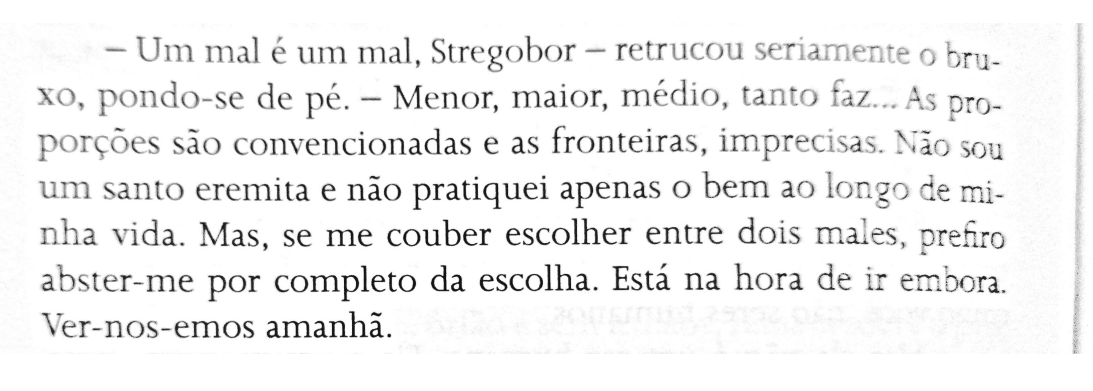

In [ ]:
img = cv2.imread('/content/trecho_livro.png')
cv2_imshow(img)

In [ ]:
!tesseract --help-psm

Page segmentation modes:
  0    Orientation and script detection (OSD) only.
  1    Automatic page segmentation with OSD.
  2    Automatic page segmentation, but no OSD, or OCR. (not implemented)
  3    Fully automatic page segmentation, but no OSD. (Default)
  4    Assume a single column of text of variable sizes.
  5    Assume a single uniform block of vertically aligned text.
  6    Assume a single uniform block of text.
  7    Treat the image as a single text line.
  8    Treat the image as a single word.
  9    Treat the image as a single word in a circle.
 10    Treat the image as a single character.
 11    Sparse text. Find as much text as possible in no particular order.
 12    Sparse text with OSD.
 13    Raw line. Treat the image as a single text line,
       bypassing hacks that are Tesseract-specific.


In [ ]:
config_tesseract = '--tessdata-dir tessdata --psm 6'

texto = pytesseract.image_to_string(img, lang='por', config = config_tesseract)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente o bry-
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... As pro-
porções são convencionadas e as fronteiras, imprecisas. Não sou
um santo eremita e não pratiquei apenas o bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro
abster-me por completo da escolha. Está na hora de ir embora. ;
Ver-nos-emos amanhã. |



In [ ]:
!apt-get install tesseract-ocr-por

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-por is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [ ]:
!tesseract --list-langs

List of available languages (3):
eng
osd
por


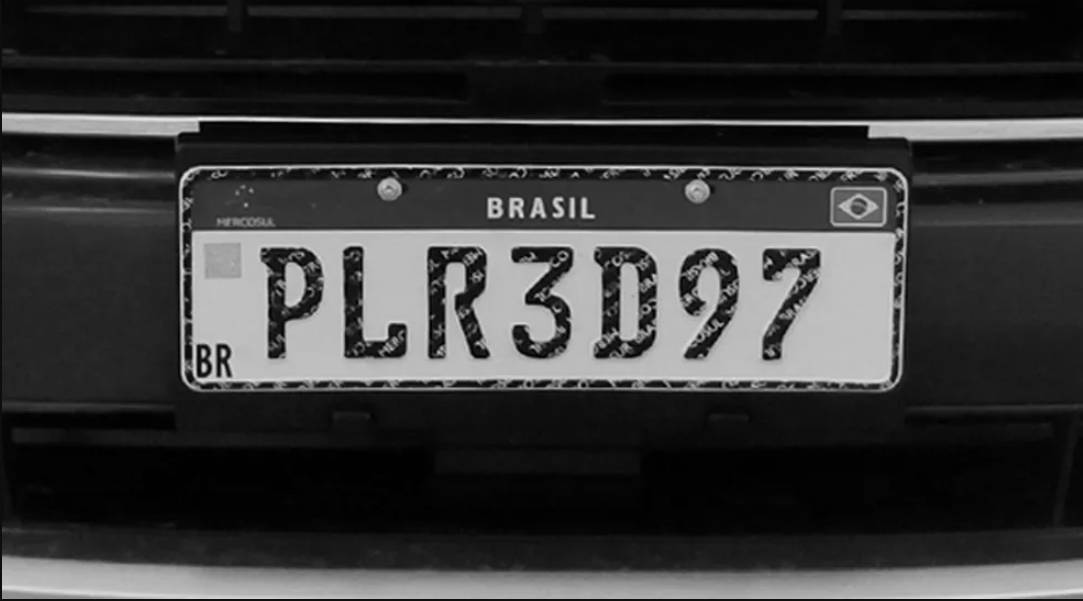

In [ ]:
img = cv2.imread('/content/placa_carro1.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

In [ ]:
texto = pytesseract.image_to_string(gray, lang='por', config = config_tesseract)
print(texto)

. PLRSD97 |
f P ,,



## Limiarização Simples

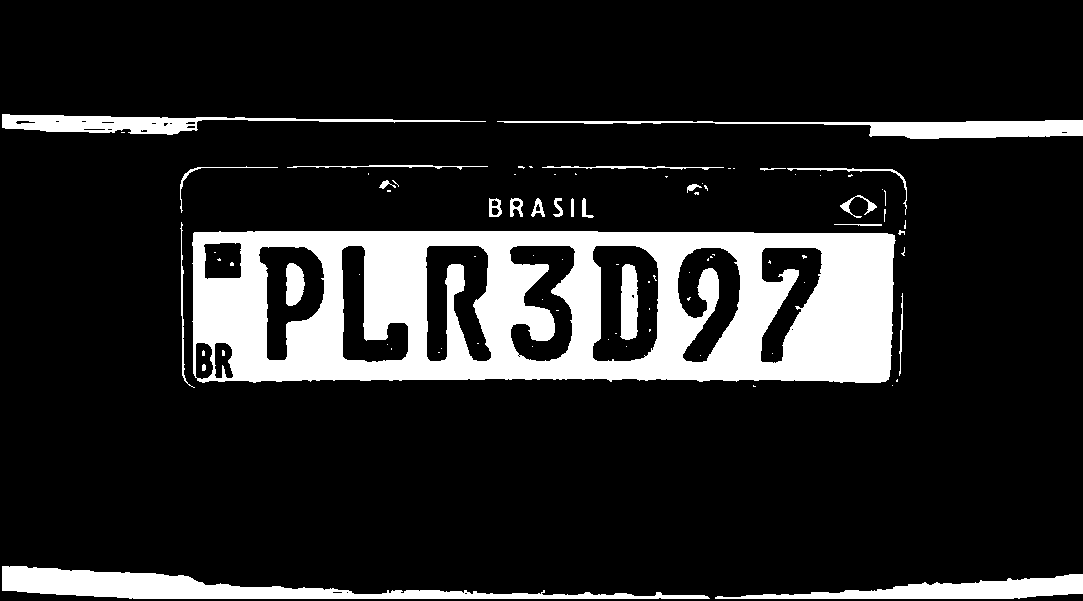

In [ ]:
limiar = 168

valor, thresh = cv2.threshold(gray, limiar, 255, cv2.THRESH_BINARY)
cv2_imshow(thresh)

## Limiarização Adaptativa (Mean ou Gaussiana)

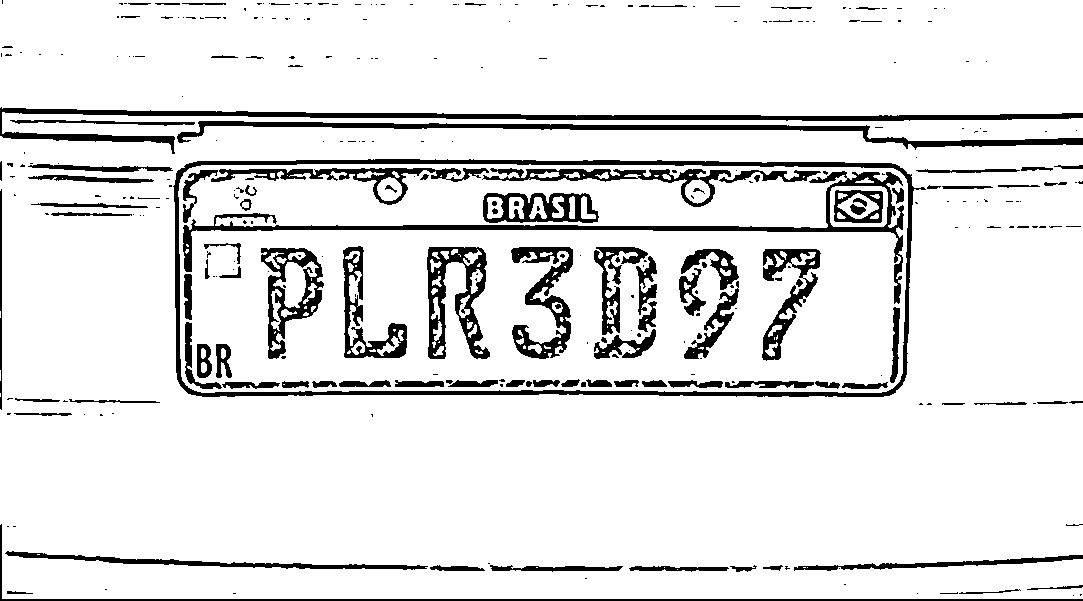

In [ ]:
lim_adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(lim_adapt)

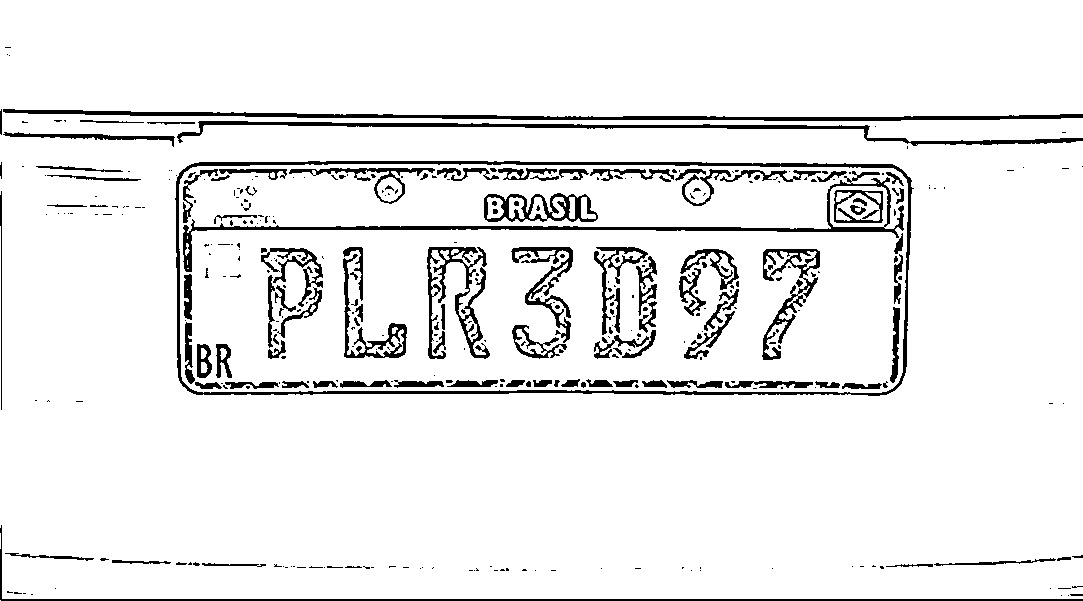

In [ ]:
lim_adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(lim_adapt)

## Limiarização de Otsu

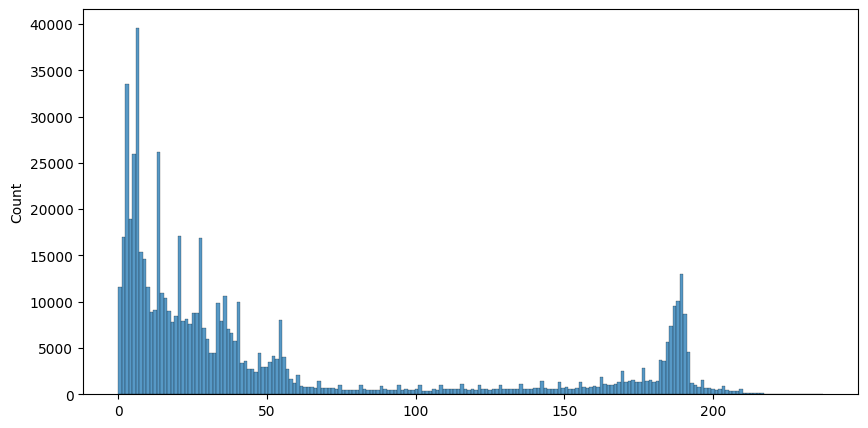

In [ ]:
import seaborn as sns

ax = sns.histplot(gray.flatten())
ax.figure.set_size_inches(10, 5)

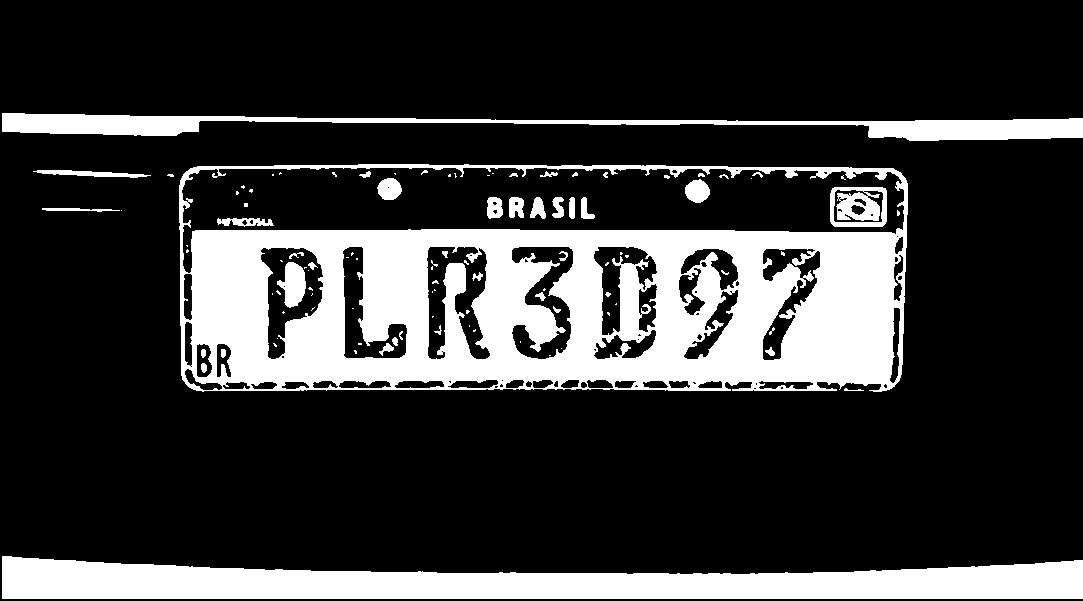


Limiar: 96.0


In [ ]:
valor, lim_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(lim_otsu)
print(f'\nLimiar: {valor}')

In [ ]:
config_tesseract = '--tessdata-dir tessdata --psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
texto = pytesseract.image_to_string(lim_otsu, lang='por', config = config_tesseract)
print(texto)

PLRSD97
AAA



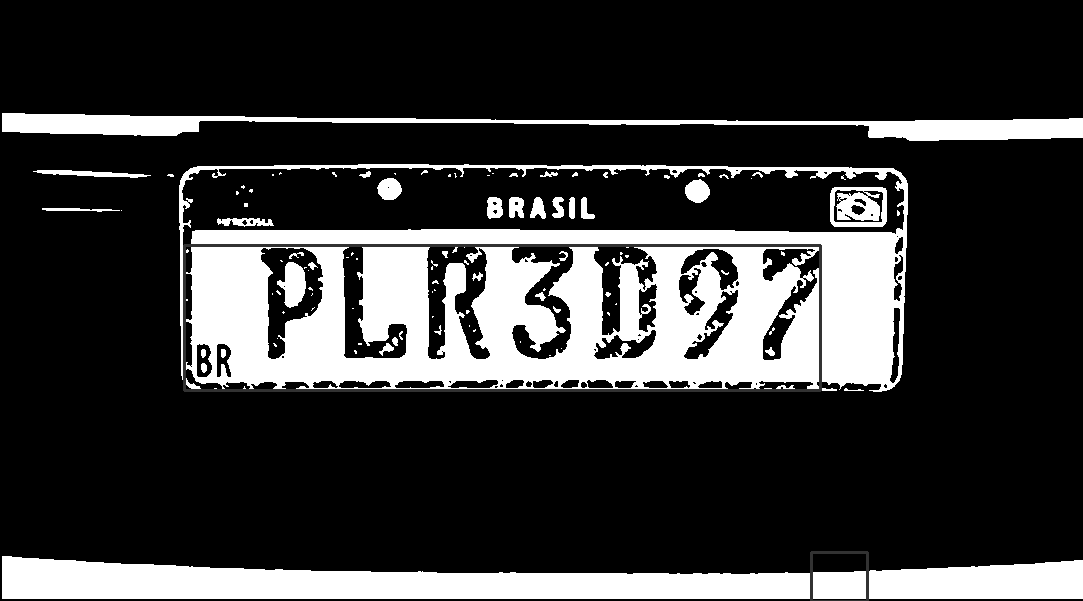

In [ ]:
lim_otsu_copia = lim_otsu.copy()
dados = pytesseract.image_to_data(lim_otsu_copia, lang='por', config=config_tesseract, output_type=pytesseract.Output.DICT)

for i in range(len(dados['text'])):
    if int(dados['conf'][i]) >= 0:
        x, y, w, h = dados['left'][i], dados['top'][i], dados['width'][i], dados['height'][i]
        cv2.rectangle(lim_otsu_copia, (x, y), (x + w, y + h), (50, 255, 0), 2)

cv2_imshow(lim_otsu_copia)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
dados

{'level': [1, 2, 3, 4, 5, 4, 5],
 'page_num': [1, 1, 1, 1, 1, 1, 1],
 'block_num': [0, 1, 1, 1, 1, 1, 1],
 'par_num': [0, 0, 1, 1, 1, 1, 1],
 'line_num': [0, 0, 0, 1, 1, 2, 2],
 'word_num': [0, 0, 0, 0, 1, 0, 1],
 'left': [0, 2, 2, 184, 184, 2, 811],
 'top': [0, 237, 237, 237, 245, 556, 552],
 'width': [1083, 1081, 1081, 719, 636, 1081, 56],
 'height': [601, 362, 362, 154, 145, 43, 49],
 'conf': [-1, -1, -1, -1, 0, -1, 0],
 'text': ['', '', '', '', 'PLRSD97', '', 'AAA']}

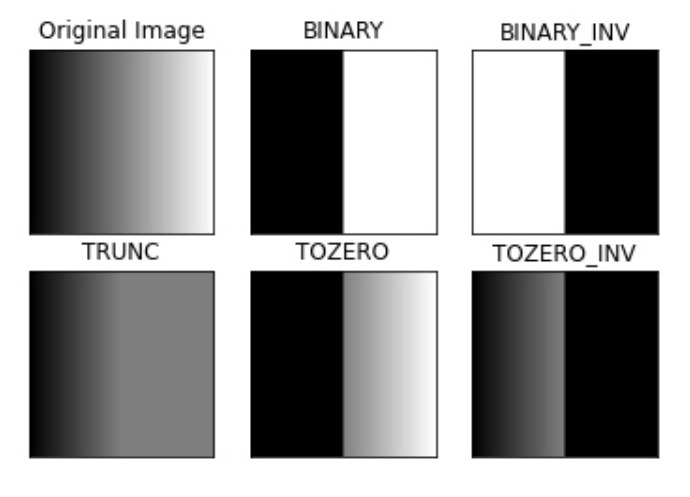

## Erosão e dilatação || abertura e fechamento

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

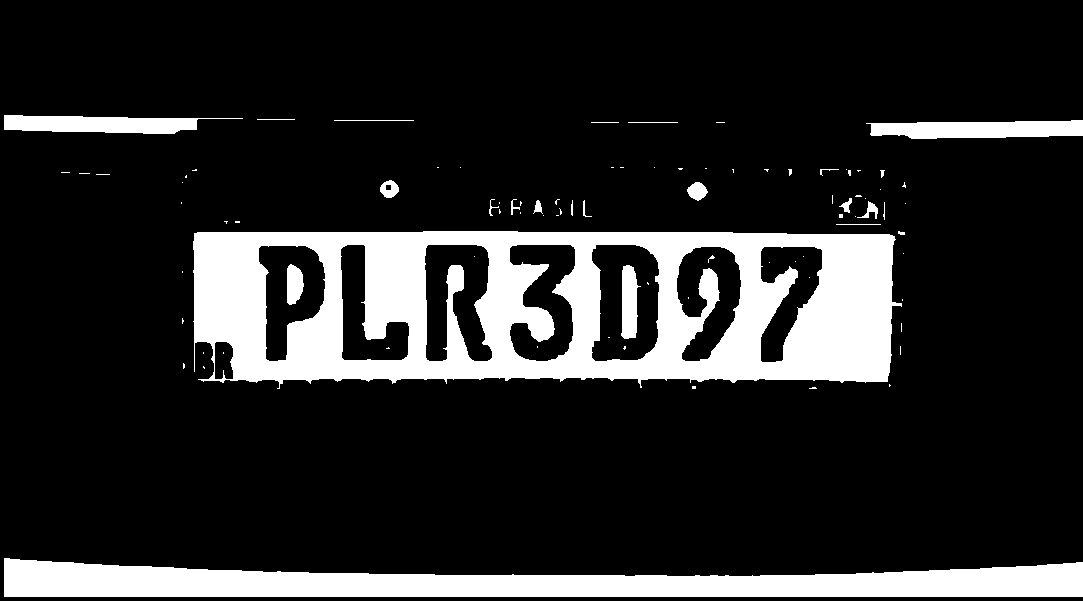

In [ ]:
erosao = cv2.erode(lim_otsu, kernel)
cv2_imshow(erosao)

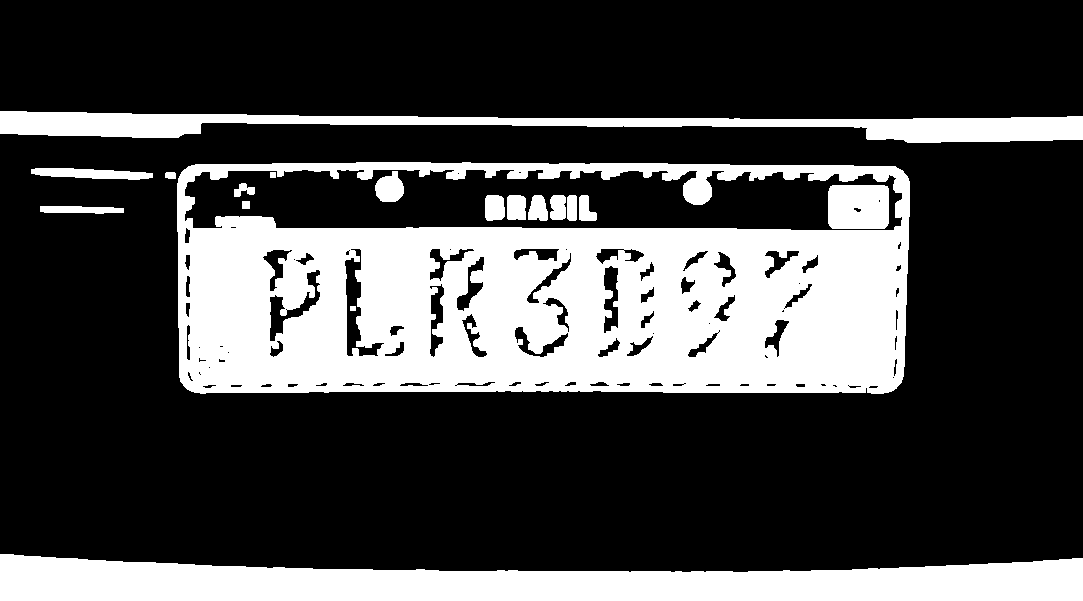

In [ ]:
dilatacao = cv2.dilate(lim_otsu, kernel)
cv2_imshow(dilatacao)

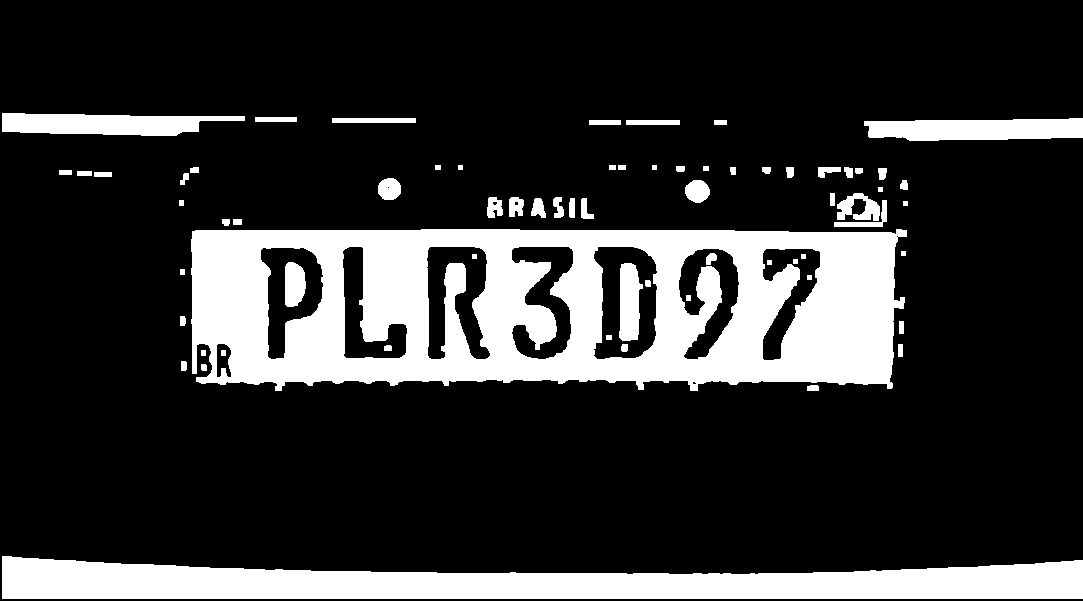

In [ ]:
abertura = cv2.morphologyEx(lim_otsu, cv2.MORPH_OPEN, kernel)
cv2_imshow(abertura)

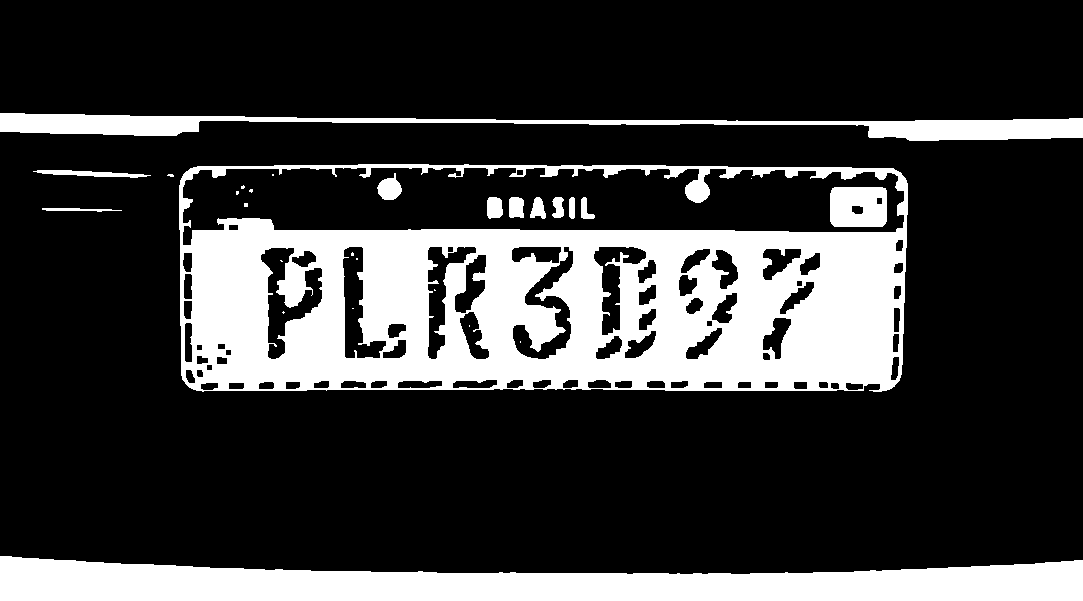

In [ ]:
fechamento = cv2.morphologyEx(lim_otsu, cv2.MORPH_CLOSE, kernel)
cv2_imshow(fechamento)

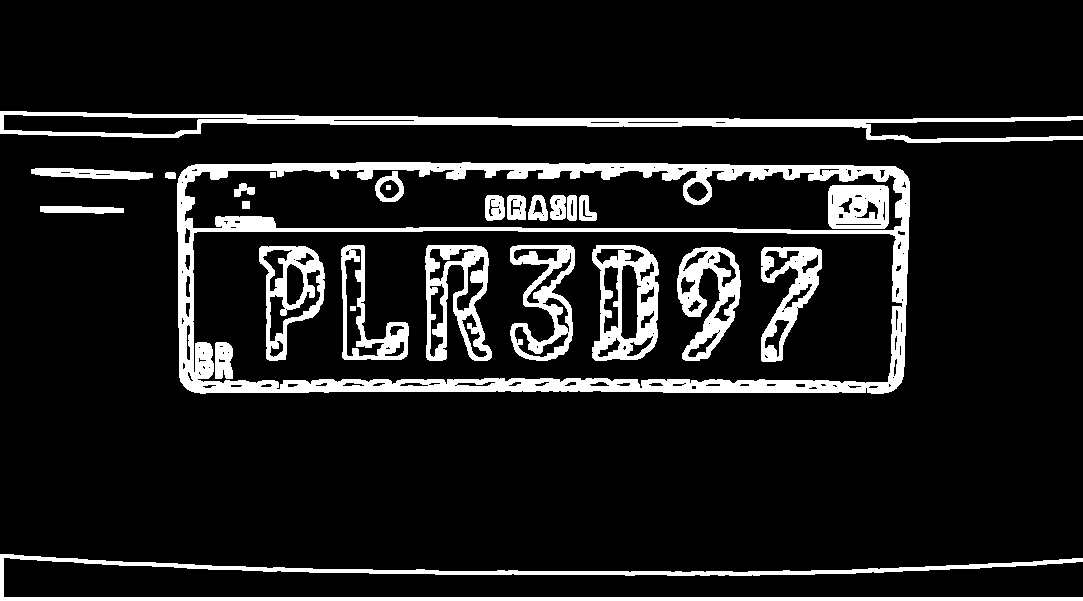

In [ ]:
gradiente = cv2.morphologyEx(lim_otsu, cv2.MORPH_GRADIENT, kernel)
cv2_imshow(gradiente)

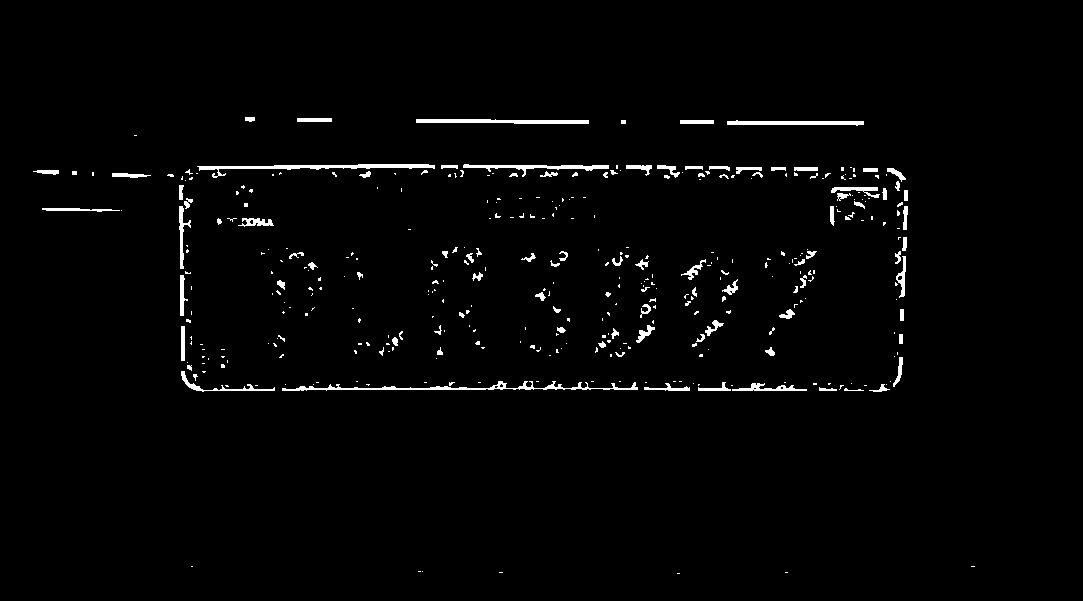

In [ ]:
cartola = cv2.morphologyEx(lim_otsu, cv2.MORPH_TOPHAT, kernel)
cv2_imshow(cartola)

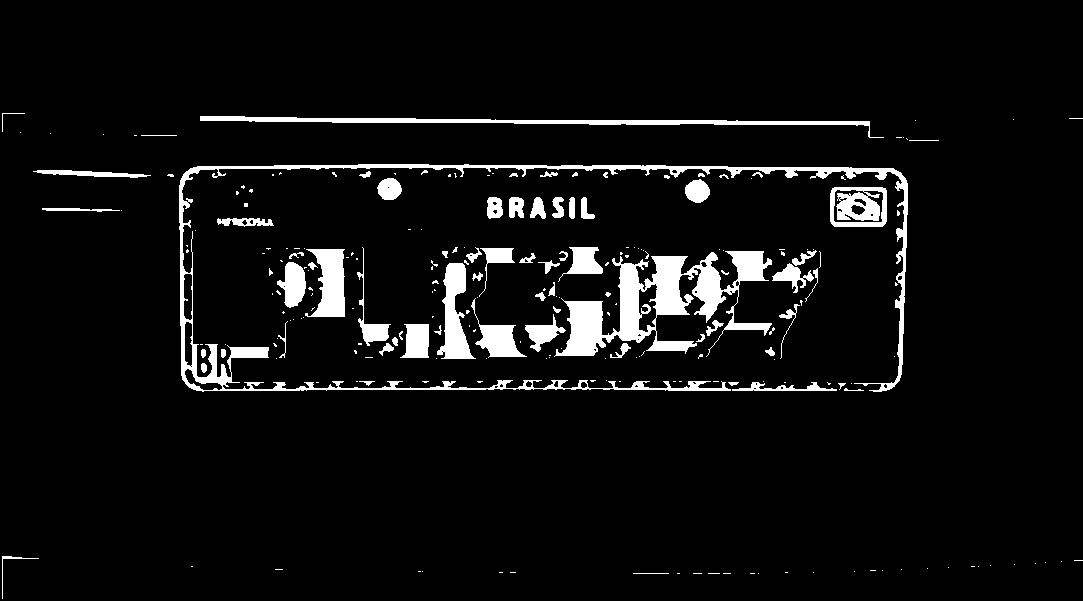

In [ ]:
kernel_ret = cv2.getStructuringElement(cv2.MORPH_RECT, (40,13))
cartola = cv2.morphologyEx(lim_otsu, cv2.MORPH_TOPHAT, kernel_ret)
cv2_imshow(cartola)

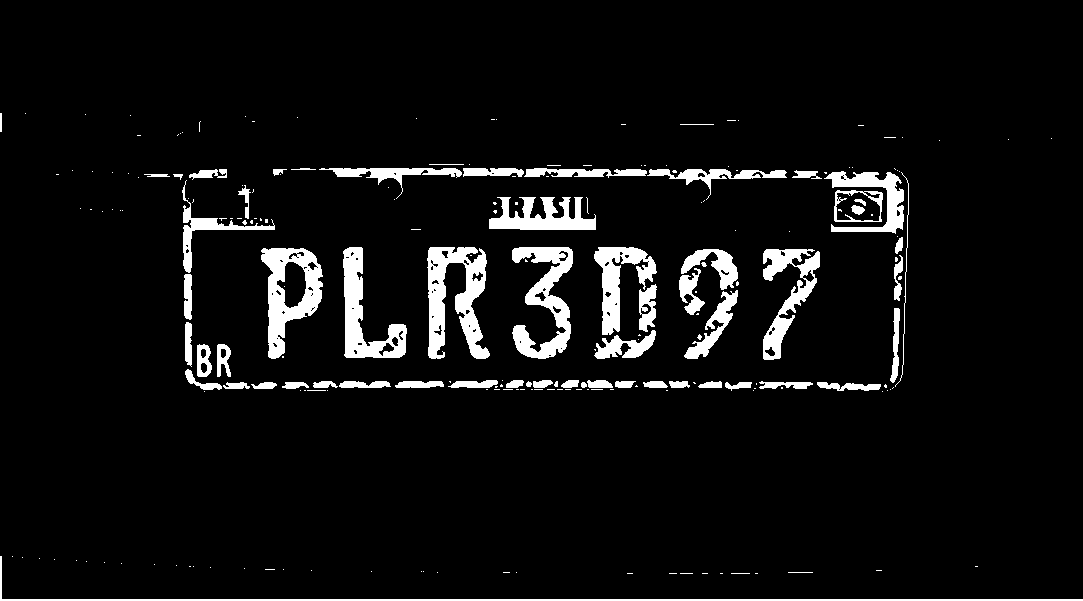

In [ ]:
black_hat = cv2.morphologyEx(lim_otsu, cv2.MORPH_BLACKHAT, kernel_ret)
cv2_imshow(black_hat )

In [ ]:
texto = pytesseract.image_to_string(lim_otsu, lang='por', config = config_tesseract)
print(texto)

PLRSD97
AAA



## Detecção de bordas

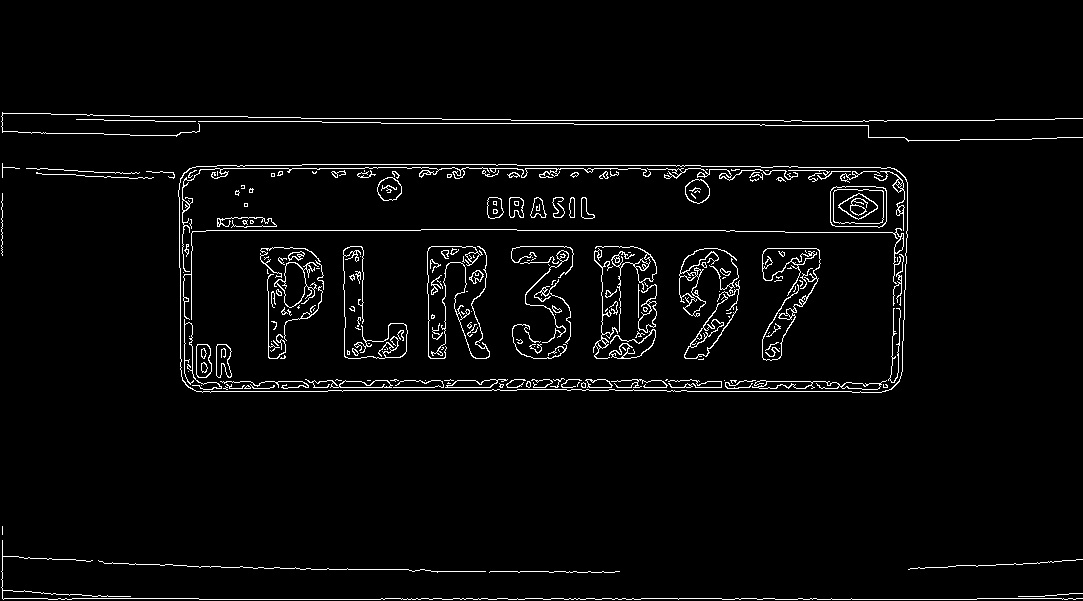

In [ ]:
bordas = cv2.Canny(gray, 100, 200)
cv2_imshow(bordas)

In [ ]:
contornos, hierarquia = cv2.findContours(bordas, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contornos

(array([[[1069,  593]],
 
        [[1068,  594]],
 
        [[1057,  594]],
 
        [[1056,  595]],
 
        [[1045,  595]],
 
        [[1044,  596]],
 
        [[1018,  596]],
 
        [[1044,  596]],
 
        [[1045,  595]],
 
        [[1056,  595]],
 
        [[1057,  594]],
 
        [[1068,  594]],
 
        [[1069,  593]],
 
        [[1082,  593]]], dtype=int32),
 array([[[490, 571]],
 
        [[489, 572]],
 
        [[490, 571]],
 
        [[517, 571]],
 
        [[518, 572]],
 
        [[519, 572]],
 
        [[520, 571]],
 
        [[548, 571]],
 
        [[549, 572]],
 
        [[553, 572]],
 
        [[554, 571]],
 
        [[565, 571]],
 
        [[566, 572]],
 
        [[568, 572]],
 
        [[569, 571]],
 
        [[570, 572]],
 
        [[572, 572]],
 
        [[573, 571]],
 
        [[576, 571]],
 
        [[577, 572]],
 
        [[587, 572]],
 
        [[588, 571]],
 
        [[590, 571]],
 
        [[591, 572]],
 
        [[601, 572]],
 
        [[602, 571]],
 

In [ ]:
hierarquia

array([[[  1,  -1,  -1,  -1],
        [  2,   0,  -1,  -1],
        [  3,   1,  -1,  -1],
        ...,
        [360, 358,  -1,  -1],
        [361, 359,  -1,  -1],
        [ -1, 360,  -1,  -1]]], dtype=int32)

In [ ]:
for contorno in contornos:
  epsilon = 0.02 * cv2.arcLength(contorno, True)
  aprox = cv2.approxPolyDP(contorno, epsilon, True)
  if cv2.isContourConvex(aprox) and len(aprox) == 4:
    localizacao = aprox
    break

localizacao

array([[[180, 178]],

       [[196, 391]],

       [[901, 375]],

       [[894, 168]]], dtype=int32)

In [ ]:
x, y ,w , h = cv2.boundingRect(localizacao)
x, y ,w , h

(180, 168, 722, 224)

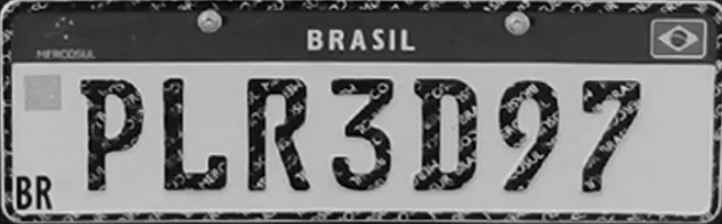

In [ ]:
placa = gray[y:y+h, x:x+w]
cv2_imshow(placa)

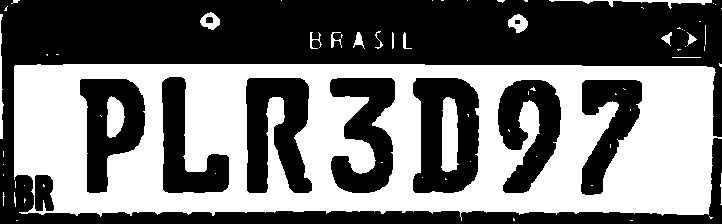

In [ ]:
valor, lim_otsu = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
erosao = cv2.erode(lim_otsu, cv2.getStructuringElement(cv2.MORPH_RECT, (4,4)))
cv2_imshow(erosao)

In [ ]:
texto = pytesseract.image_to_string(erosao, lang='por', config = config_tesseract)
print(texto)

LPLR3D97



In [ ]:
import re

texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
texto_extraido

<re.Match object; span=(1, 8), match='PLR3D97'>

In [ ]:
print(texto_extraido.group(0))

PLR3D97


## Aplicando em nova imagem

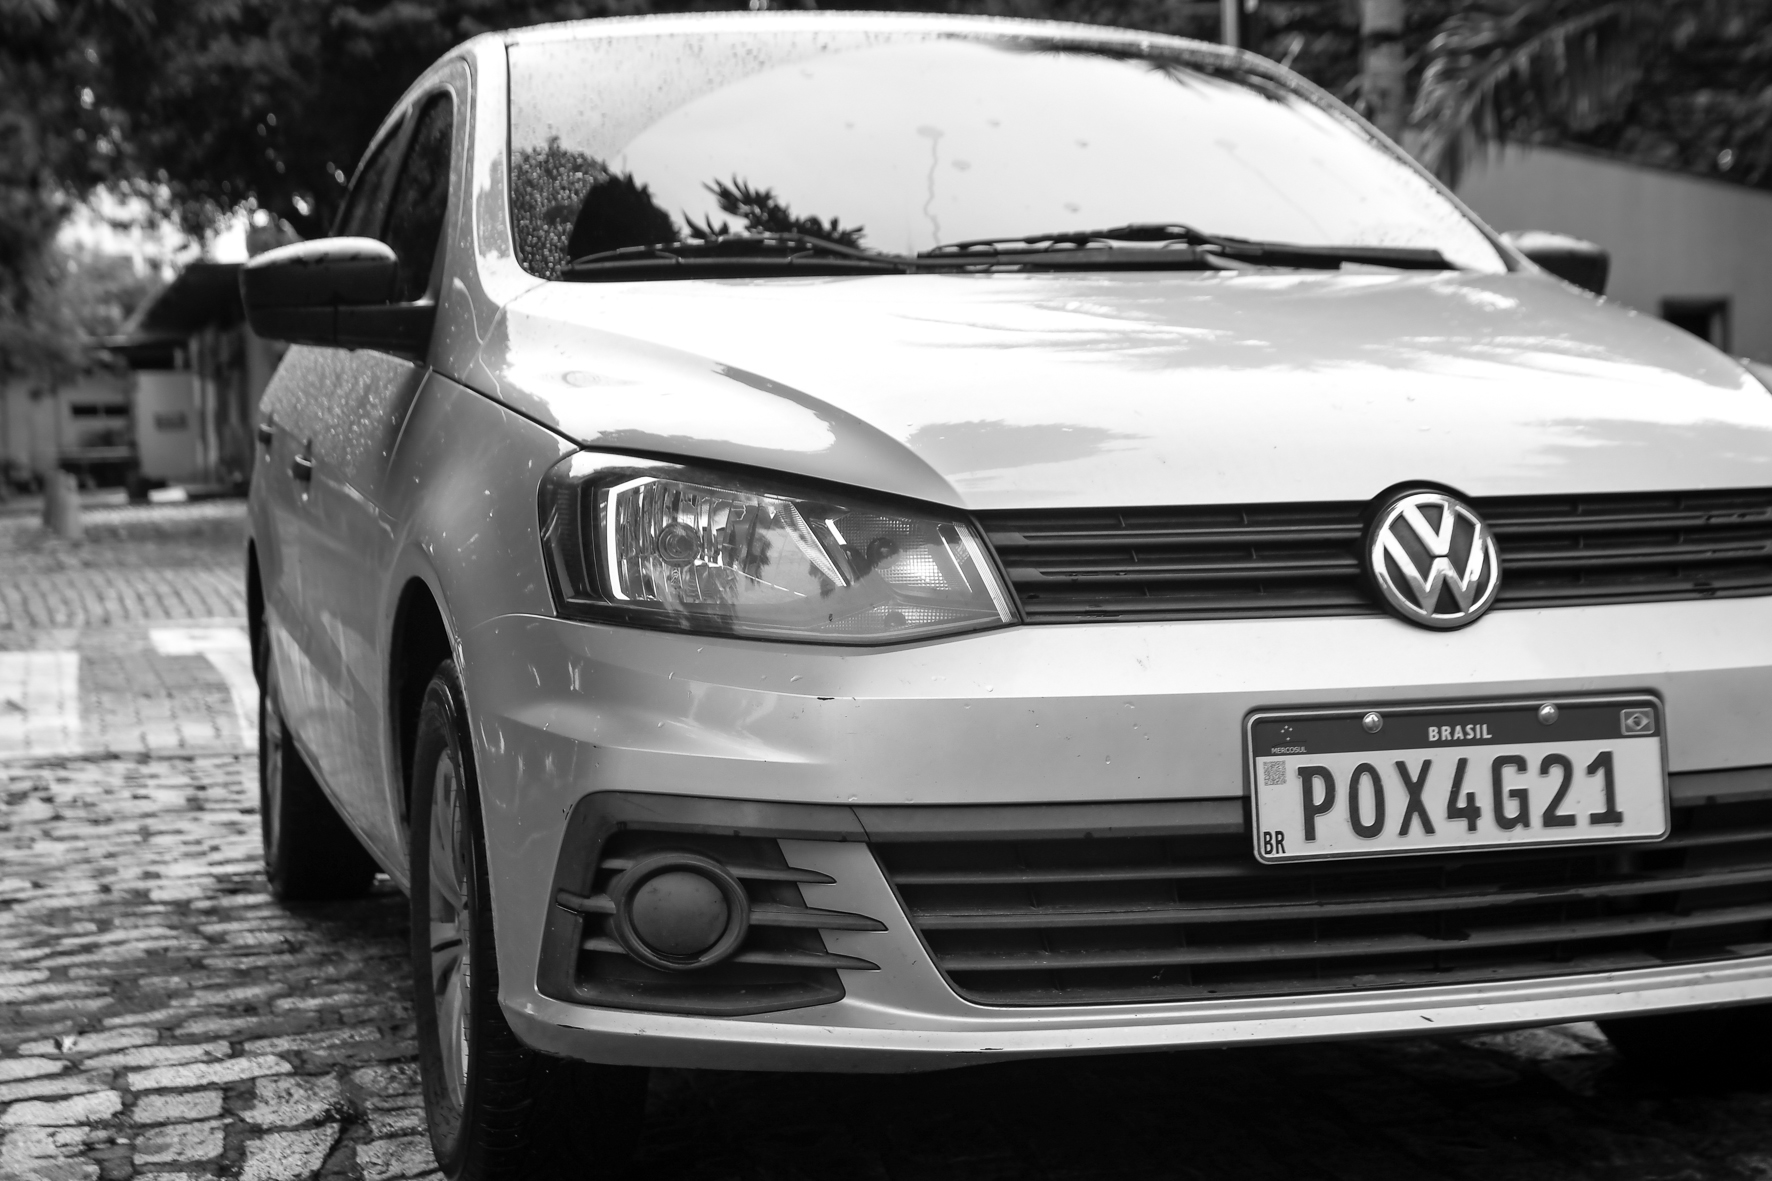

In [ ]:
img = cv2.imread('/content/placa_carro2.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(img)

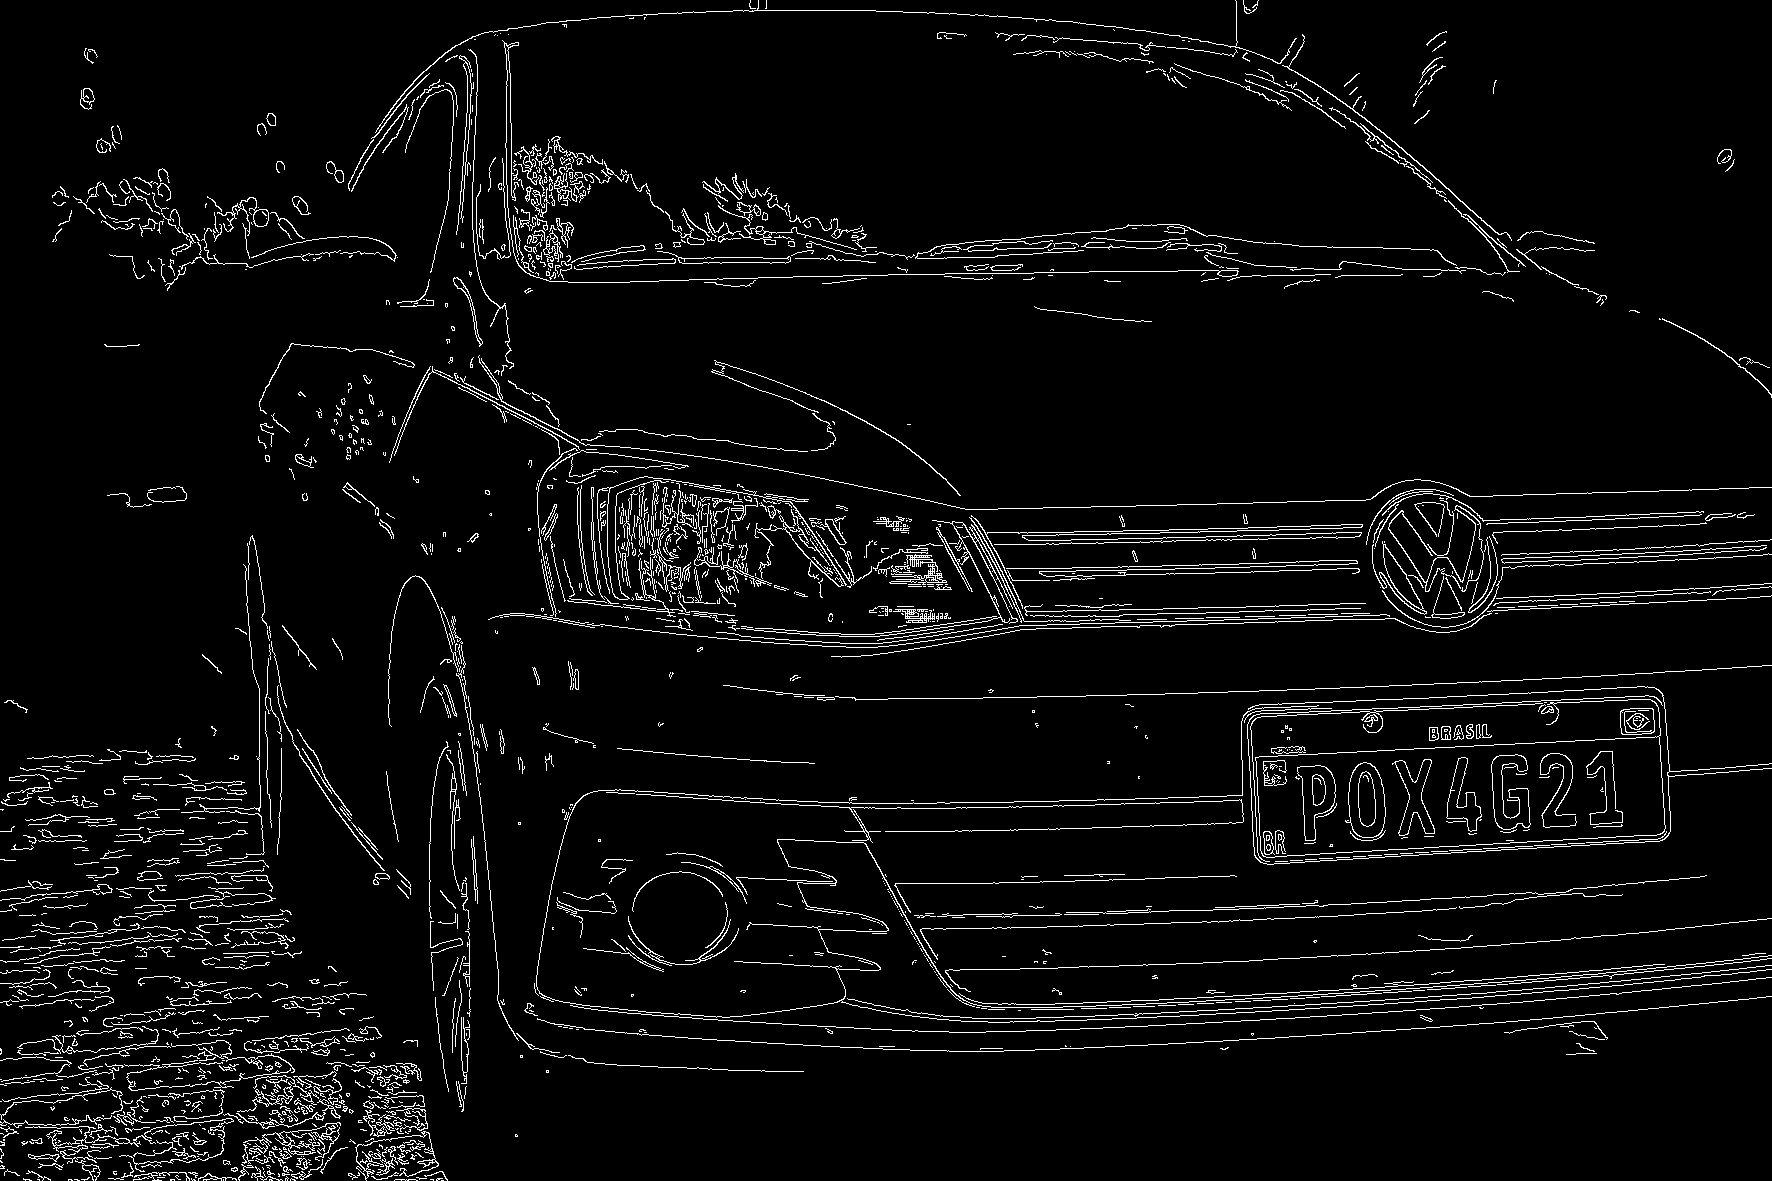

In [ ]:
bordas = cv2.Canny(img, 100, 200)
cv2_imshow(bordas)

In [ ]:
contornos, hierarquia = cv2.findContours(bordas, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key = cv2.contourArea, reverse = True)[:10]

for contorno in contornos:
  epsilon = 0.02 * cv2.arcLength(contorno, True)
  aprox = cv2.approxPolyDP(contorno, epsilon, True)
  if cv2.isContourConvex(aprox) and len(aprox) == 4:
    localizacao = aprox
    break

localizacao

array([[[1659,  737]],

       [[1656,  835]],

       [[1260,  850]],

       [[1259,  756]]], dtype=int32)

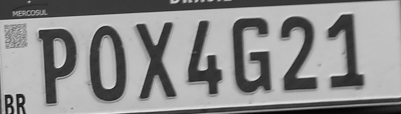

In [ ]:
x, y, w, h = cv2.boundingRect(localizacao)

placa = img[y:y+h, x:x+w]
cv2_imshow(placa)

Não precisa de erosão, pois não possui falhas nos caracteres como na primeira imagem

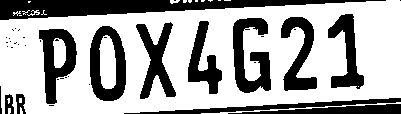

In [ ]:
valor, lim_otsu = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(lim_otsu)

In [ ]:
texto = pytesseract.image_to_string(lim_otsu, lang='por', config = config_tesseract)
print(texto)

POX4G21



In [ ]:
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
print(texto_extraido.group(0))

POX4G21


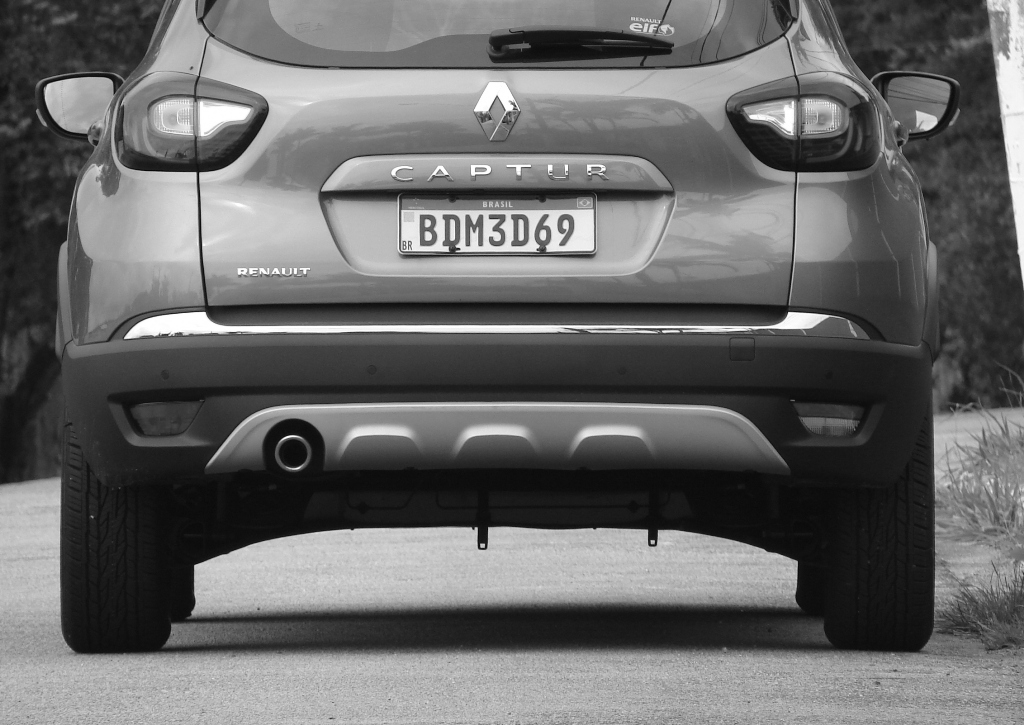

In [ ]:
img = cv2.imread('/content/placa_carro3.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(img)

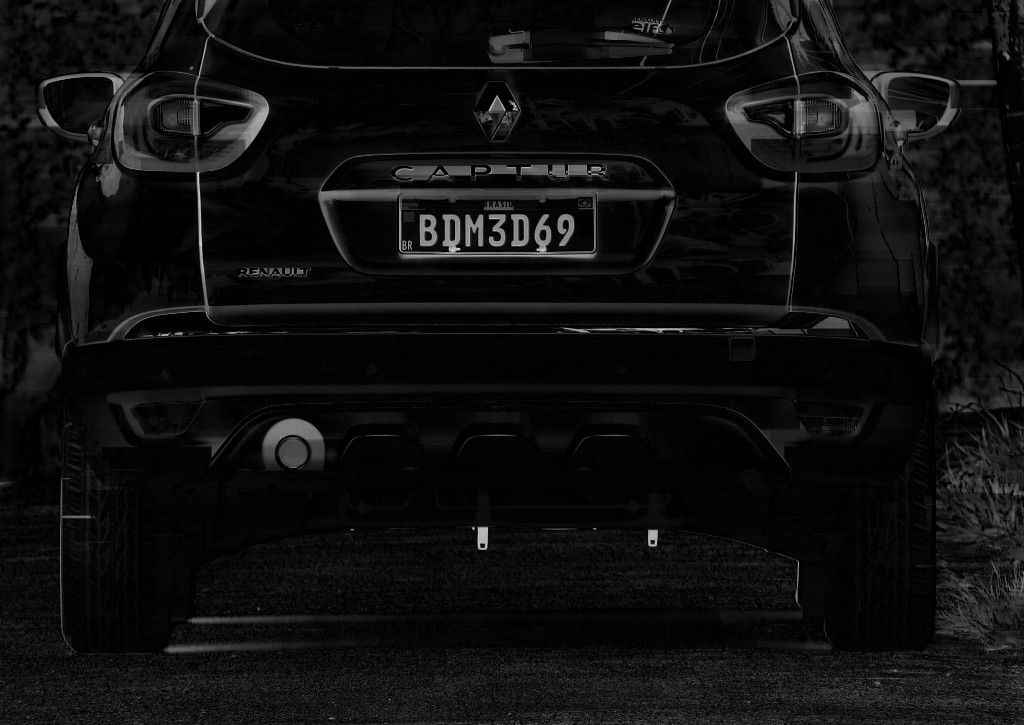

In [ ]:
black_hat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel_ret)
cv2_imshow(black_hat)

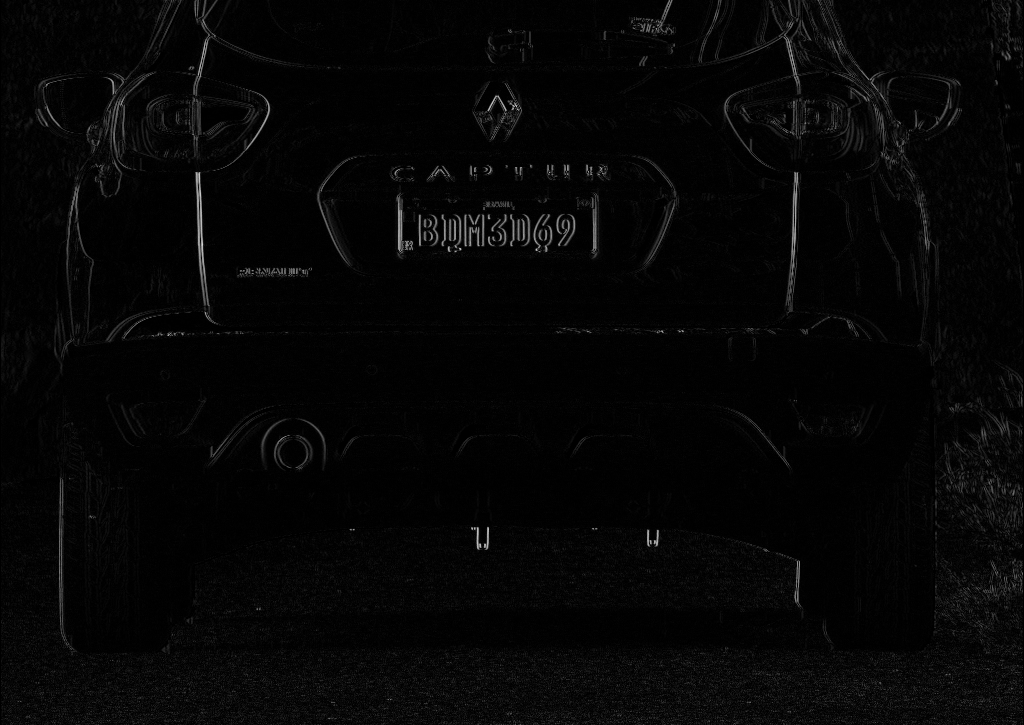

In [ ]:
sobel_x = cv2.Sobel(black_hat, ddepth = cv2.CV_32F, dx = 1, dy = 0, ksize = 1)
sobel_x = np.absolute(sobel_x)
sobel_x = sobel_x.astype('uint8')
cv2_imshow(sobel_x)

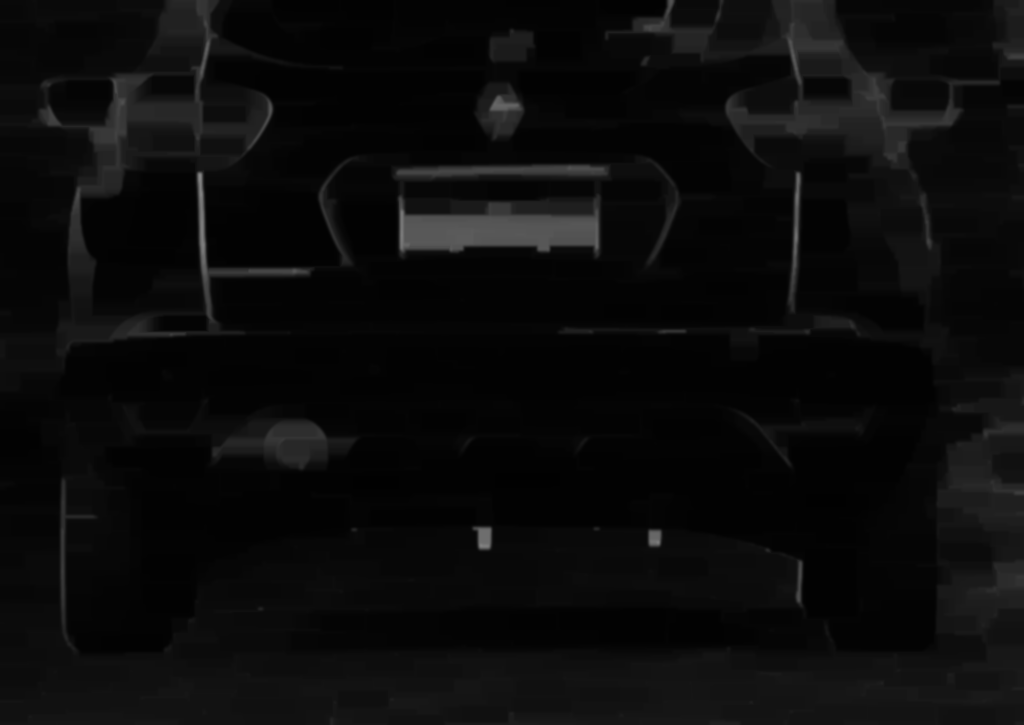

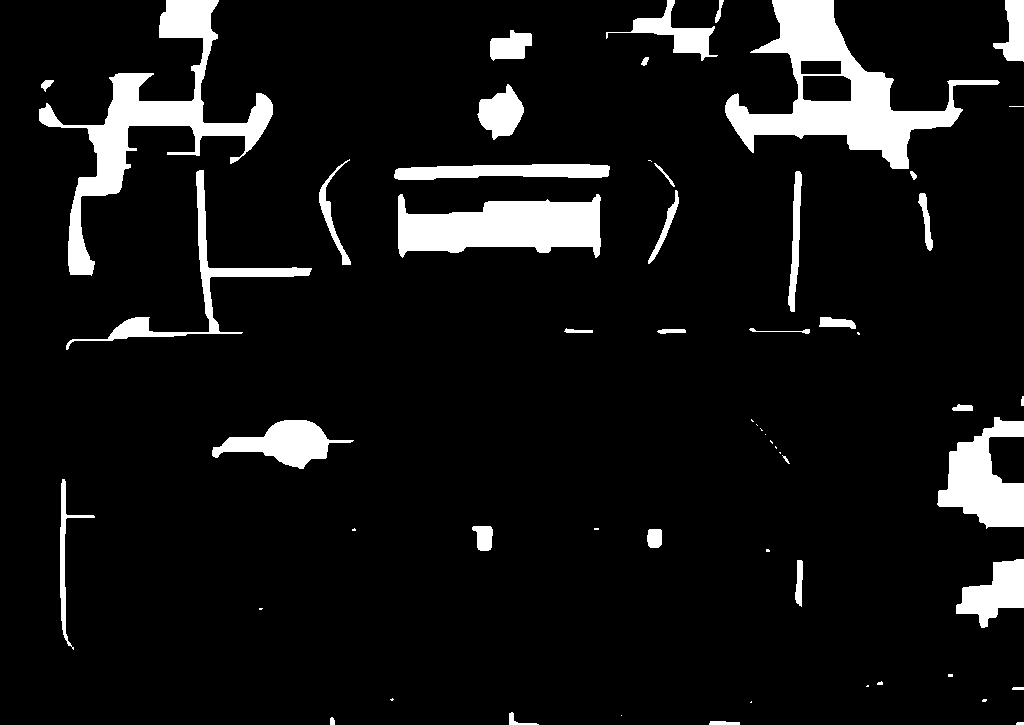

In [ ]:
sobel_x = cv2.GaussianBlur(sobel_x, (5,5), 0)
sobel_x = cv2.morphologyEx(sobel_x, cv2.MORPH_CLOSE, kernel_ret)
cv2_imshow(sobel_x)
valor, limiarizacao = cv2.threshold(sobel_x, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2_imshow(limiarizacao)

In [ ]:
kernel_qd = cv2.getStructuringElement(cv2.MORPH_RECT, (3 ,3))
kernel_qd

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

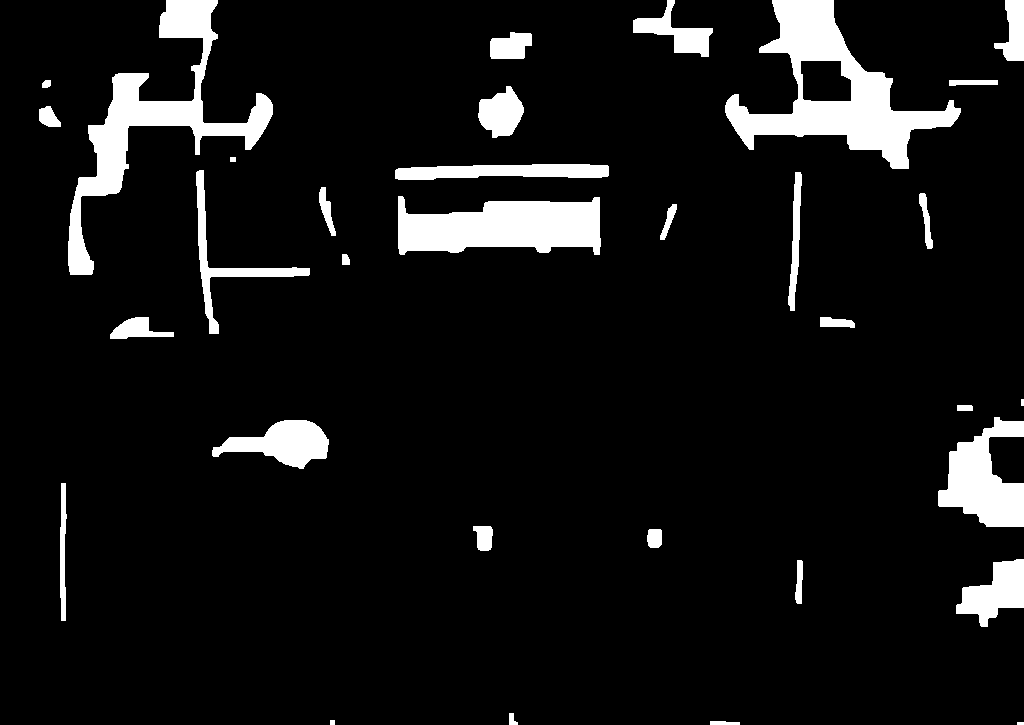

In [ ]:
limiarizacao = cv2.erode(limiarizacao, kernel_qd, iterations = 2)
limiarizacao = cv2.dilate(limiarizacao, kernel_qd, iterations = 2)
cv2_imshow(limiarizacao)

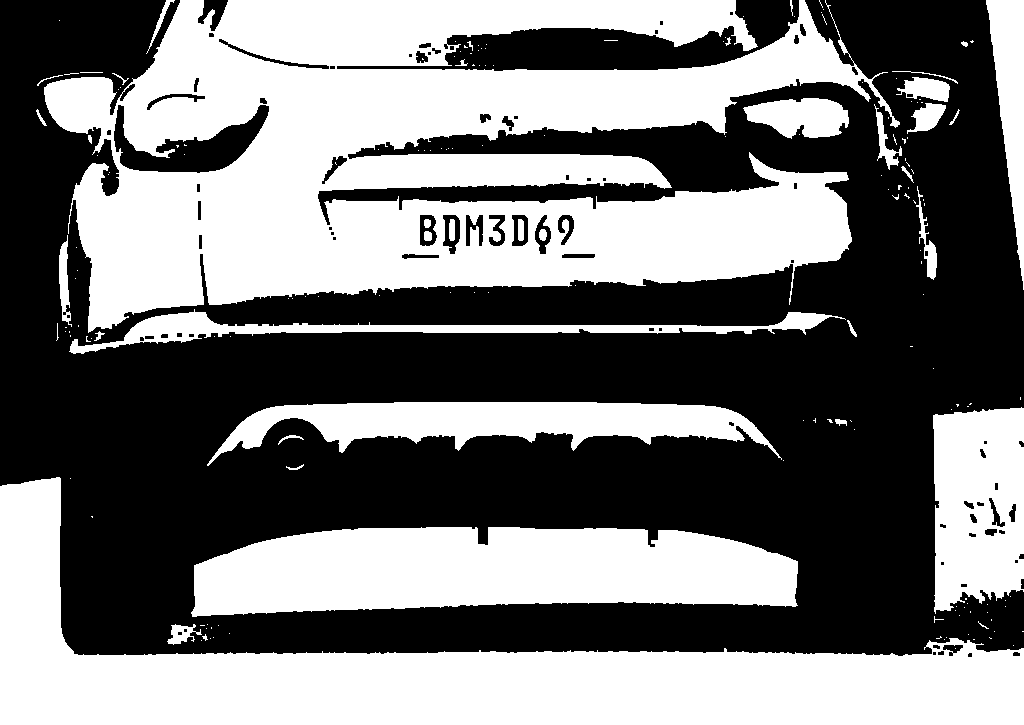

In [ ]:
fechamento = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_qd)
valor, mascara = cv2.threshold(fechamento, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(mascara)

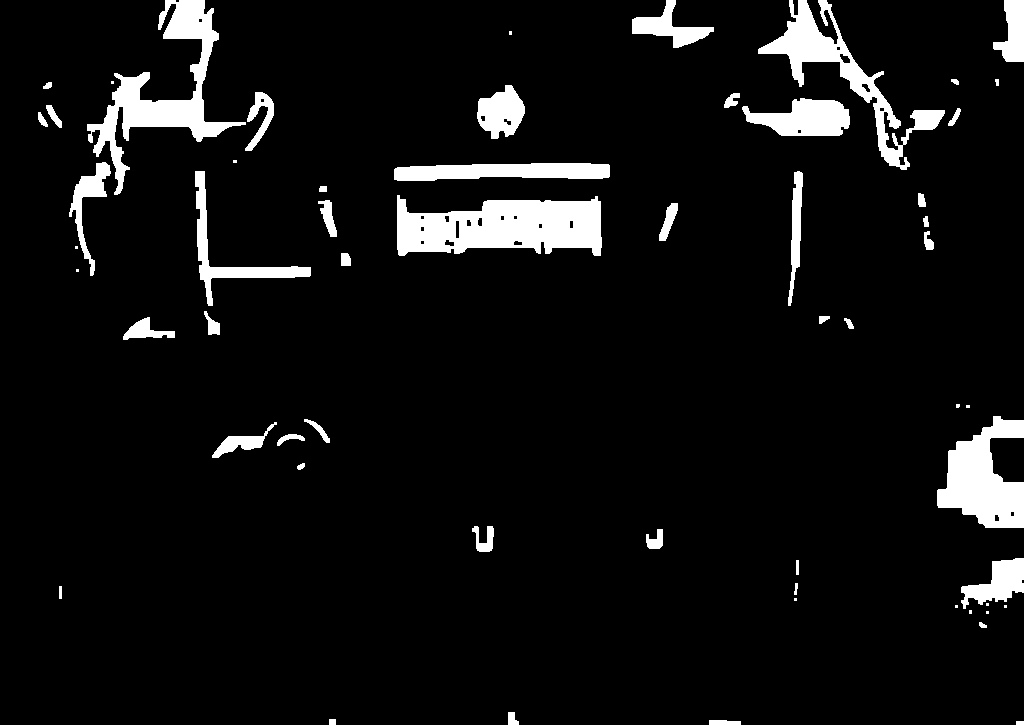

In [ ]:
limiarizacao = cv2.bitwise_and(limiarizacao, limiarizacao, mask = mascara)
limiarizacao = cv2.dilate(limiarizacao, kernel_qd, iterations = 2)
limiarizacao = cv2.erode(limiarizacao, kernel_qd)
cv2_imshow(limiarizacao)

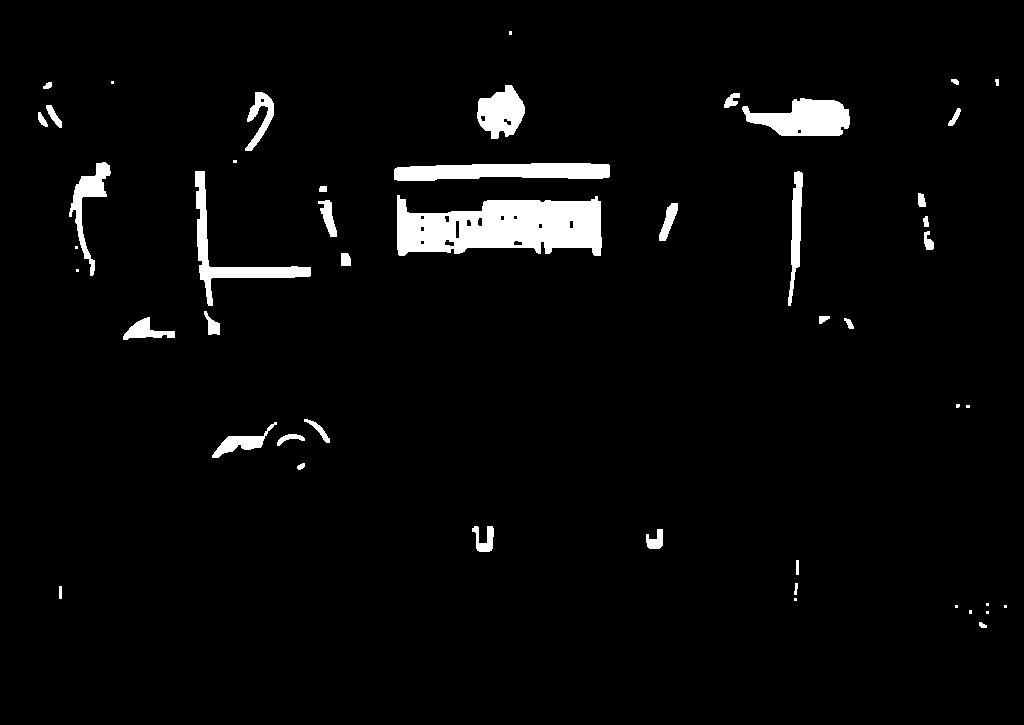

In [ ]:
from skimage.segmentation import clear_border

limiarizacao = clear_border(limiarizacao)
cv2_imshow(limiarizacao)

In [ ]:
contornos, hierarquia = cv2.findContours(limiarizacao, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key = cv2.contourArea, reverse = True)[:10]
contornos

[array([[[397, 195]],
 
        [[397, 249]],
 
        [[398, 250]],
 
        [[398, 254]],
 
        [[399, 255]],
 
        [[404, 255]],
 
        [[408, 251]],
 
        [[446, 251]],
 
        [[447, 252]],
 
        [[450, 252]],
 
        [[450, 249]],
 
        [[451, 248]],
 
        [[453, 248]],
 
        [[454, 249]],
 
        [[454, 253]],
 
        [[459, 253]],
 
        [[460, 252]],
 
        [[462, 252]],
 
        [[463, 251]],
 
        [[464, 251]],
 
        [[464, 250]],
 
        [[467, 247]],
 
        [[533, 247]],
 
        [[535, 249]],
 
        [[535, 250]],
 
        [[536, 251]],
 
        [[536, 252]],
 
        [[537, 252]],
 
        [[538, 253]],
 
        [[540, 253]],
 
        [[540, 242]],
 
        [[541, 241]],
 
        [[543, 241]],
 
        [[544, 242]],
 
        [[544, 247]],
 
        [[545, 248]],
 
        [[545, 253]],
 
        [[549, 253]],
 
        [[551, 251]],
 
        [[551, 248]],
 
        [[552, 247]],
 
        [[591, 2

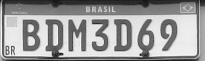

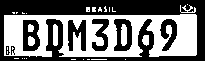

In [ ]:
for contorno in contornos:
  x, y, w, h = cv2.boundingRect(contorno)
  proporcao = float(w)/h
  if proporcao >=3 and proporcao <=3.5:
    placa = img[y:y+h, x:x+w]
    valor, regiao_interesse = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    regiao_interesse = clear_border(regiao_interesse)
    cv2_imshow(placa)
    cv2_imshow(regiao_interesse)

In [ ]:
texto = pytesseract.image_to_string(regiao_interesse, lang='por', config = config_tesseract)
print(texto)

BDM3D69



In [ ]:
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
print(texto_extraido.group(0))

BDM3D69


## Pontos importantes

* Instalar a ferramenta Tesseract;
* Utilizar o Tesseract para detectar textos em imagens;
* Identificar o melhor modo de segmentação de página de acordo com o contexto;
* Converter imagens para a escala de cinza utilizando o OpenCV.
* Diferenciar os diferentes tipos de limiarização existentes;
* Selecionar o método de limiarização mais adequado para as imagens;
* Aplicar os métodos de limiarização em imagens.
* Identificar ruídos na imagem;
* Diferenciar os diferentes tipos de transformações morfológicas existentes;
* Descrever os objetivos de cada transformação morfológica;
* Selecionar o melhor tipo de transformação de acordo com o contexto;
* Aplicar transformações morfológicas em imagens limiarizadas e em escala de cinza.
* Aplicar algoritmos para detectar bordas de objetos em imagens;
* Explicar os passos do algoritmo de Canny;
* Encontrar a região da placa de um veículo em uma imagem;
* Utilizar o regex para validar textos e extrair a informação necessária.
* Utilizar máscaras para filtrar regiões em imagens;
* Explicar e aplicar o efeito Sobel em imagens;
* Aplicar a segmentação de remoção de bordas em imagens;
* Encontrar a região da placa de um veículo em uma imagem de uma forma alternativa.